## Table of Contents


In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
import random
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

# sklearn metrics
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    brier_score_loss
)

# sklearn calibration
from sklearn.calibration import calibration_curve

# UCI dataset loader
from ucimlrepo import fetch_ucirepo

# Local project imports
sys.path.append(str(Path.cwd().parent / "src"))
from clinical_risk.train_eval import (
    evaluate_at_threshold,
    threshold_analysis
)
from clinical_risk.plotting import (
    plot_pred_proba_hist
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", context="notebook")
seed = 891
random.seed(seed)
np.random.seed(seed)

# 1 DATA LOADING

In [2]:
# Load data
data = fetch_ucirepo(id=519)
X    = data.data.features 
y    = data.data.targets

#Define constants
reduced_vars = ['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium', 'time']

#Spit
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=seed
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train event rate:", y_train.mean())
print("Test event rate:", y_test.mean())

Train shape: (239, 12)
Test shape: (60, 12)
Train event rate: death_event   0.3222
dtype: float64
Test event rate: death_event   0.3167
dtype: float64


# 2. Model training

In [3]:
# Normal pipeline
base_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=seed))
])

# Clone the same pipeline for each model
full_model = clone(base_pipeline)
reduced_model = clone(base_pipeline)

# Fit
full_model.fit(X_train, y_train)
reduced_model.fit(X_train[reduced_vars], y_train)

# Predict probabilities
y_prob_full = full_model.predict_proba(X_test)[:, 1]
y_prob_reduced = reduced_model.predict_proba(X_test[reduced_vars])[:, 1]

# 3. Evaluate model discrimination and performance

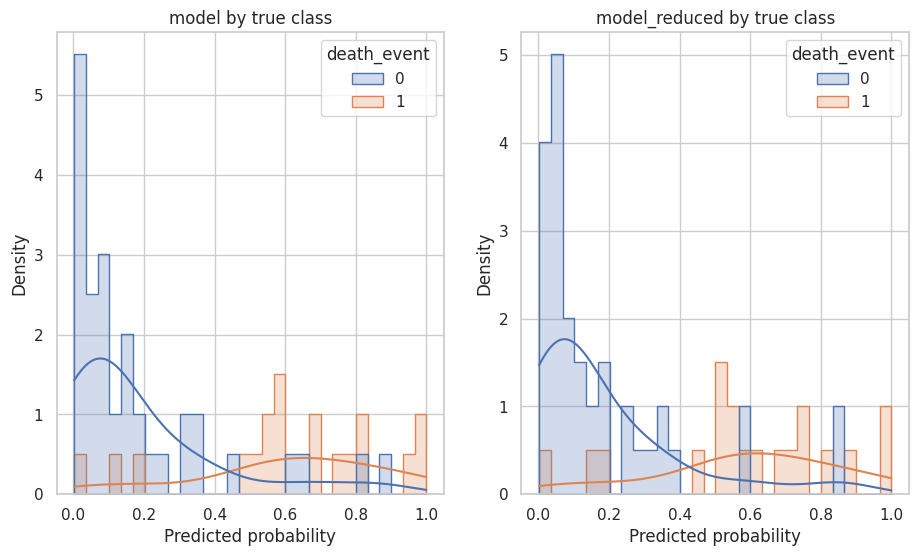

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 6))
probs = y_test.copy()
probs[["model", "model_reduced"]] = np.column_stack((y_prob_full, y_prob_reduced))

for a,m in zip(axes,["model", "model_reduced"]):
    plot_pred_proba_hist(
        a,
        probs,
        col= m,
        target_col= "death_event")

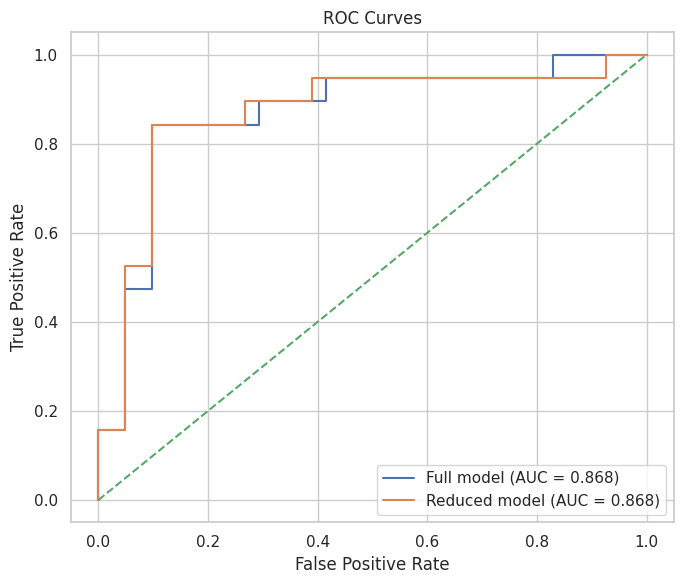

In [5]:
fpr_full, tpr_full, _ = roc_curve(y_test, y_prob_full)
fpr_reduced, tpr_reduced, _ = roc_curve(y_test, y_prob_reduced)

auc_full = roc_auc_score(y_test, y_prob_full)
auc_reduced = roc_auc_score(y_test, y_prob_reduced)

plt.figure(figsize=(7, 6))
plt.plot(fpr_full, tpr_full, label=f"Full model (AUC = {auc_full:.3f})")
plt.plot(fpr_reduced, tpr_reduced, label=f"Reduced model (AUC = {auc_reduced:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
auc_comparison = pd.DataFrame({
    "model": ["full", "reduced"],
    "roc_auc": [auc_full, auc_reduced]
})

auc_comparison

,model,roc_auc
0,full,0.8678
1,reduced,0.8678


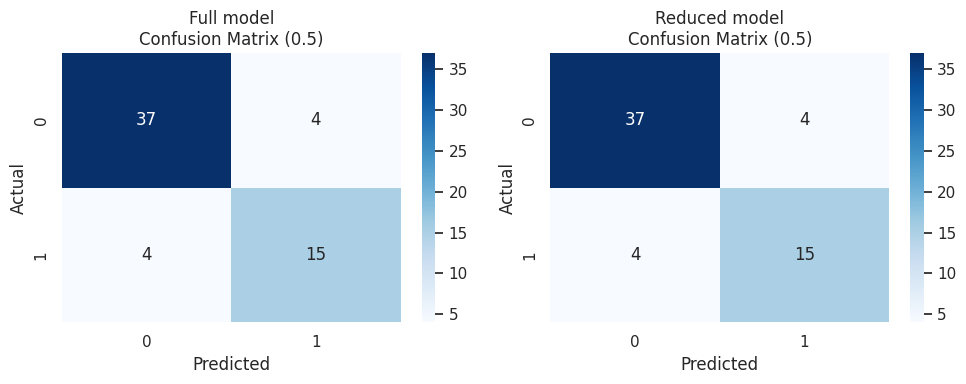

In [7]:
eval_full_05 = evaluate_at_threshold(y_test, y_prob_full, threshold=0.5)
eval_reduced_05 = evaluate_at_threshold(y_test, y_prob_reduced, threshold=0.5)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(eval_full_05["confusion_matrix"], annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Full model\nConfusion Matrix (0.5)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(eval_reduced_05["confusion_matrix"], annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Reduced model\nConfusion Matrix (0.5)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [8]:
threshold_metrics = pd.DataFrame({
    "model": ["full", "reduced"],
    "precision": [eval_full_05["precision"], eval_reduced_05["precision"]],
    "recall": [eval_full_05["recall"], eval_reduced_05["recall"]],
    "f1": [eval_full_05["f1"], eval_reduced_05["f1"]],
    "specificity": [eval_full_05["specificity"], eval_reduced_05["specificity"]]
})

threshold_metrics

,model,precision,recall,f1,specificity
0,full,0.7895,0.7895,0.7895,0.9024
1,reduced,0.7895,0.7895,0.7895,0.9024


# Calibration curve

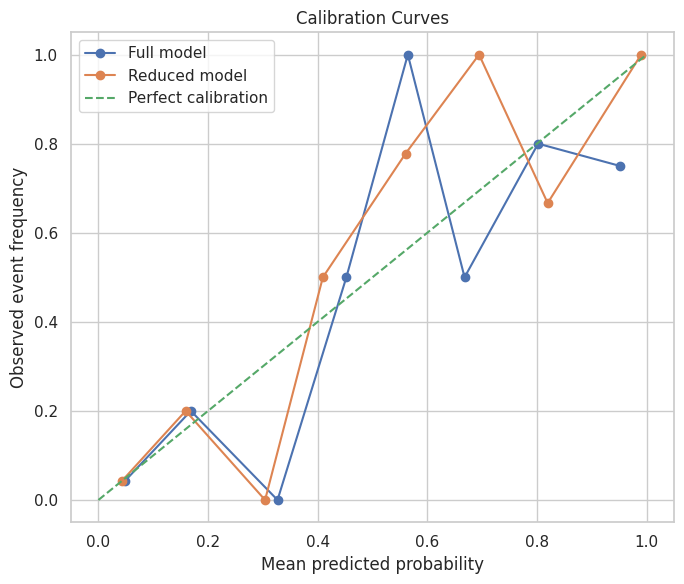

In [9]:
prob_true_full, prob_pred_full = calibration_curve(y_test, y_prob_full, n_bins=8, strategy="uniform")
prob_true_reduced, prob_pred_reduced = calibration_curve(y_test, y_prob_reduced, n_bins=8, strategy="uniform")

plt.figure(figsize=(7, 6))
plt.plot(prob_pred_full, prob_true_full, marker="o", label="Full model")
plt.plot(prob_pred_reduced, prob_true_reduced, marker="o", label="Reduced model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed event frequency")
plt.title("Calibration Curves")
plt.legend()
plt.tight_layout()
plt.show()


## brier score

In [10]:
brier_full = brier_score_loss(y_test, y_prob_full)
brier_reduced = brier_score_loss(y_test, y_prob_reduced)

brier_df = pd.DataFrame({
    "model": ["full", "reduced"],
    "brier_score": [brier_full, brier_reduced]
})

brier_df

,model,brier_score
0,full,0.1252
1,reduced,0.1256


# Threshold calibration

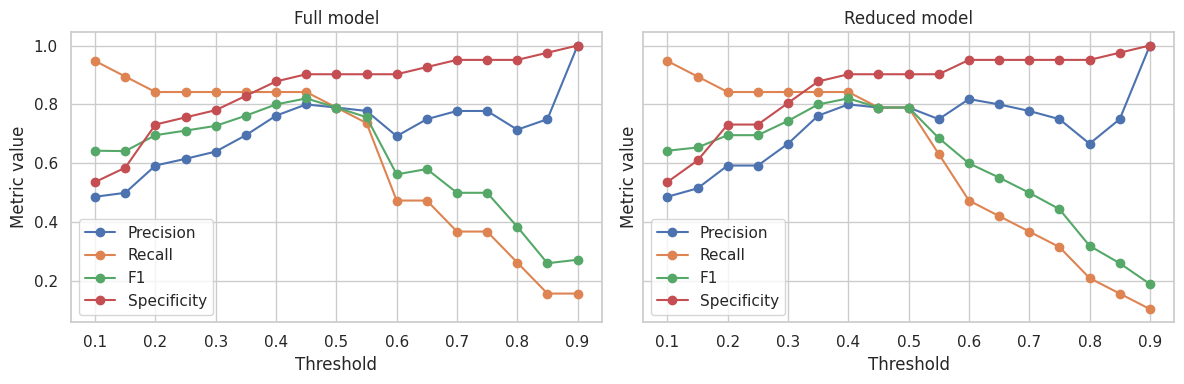

In [11]:
thresholds_full = threshold_analysis(y_test, y_prob_full, "full")
thresholds_reduced = threshold_analysis(y_test, y_prob_reduced, "reduced")
thresholds_df = pd.concat([thresholds_full, thresholds_reduced], ignore_index=True)


fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for model_name, ax in zip(["full", "reduced"], axes):
    tmp = thresholds_df[thresholds_df["model"] == model_name]
    ax.plot(tmp["threshold"], tmp["precision"], marker="o", label="Precision")
    ax.plot(tmp["threshold"], tmp["recall"], marker="o", label="Recall")
    ax.plot(tmp["threshold"], tmp["f1"], marker="o", label="F1")
    ax.plot(tmp["threshold"], tmp["specificity"], marker="o", label="Specificity")
    ax.set_title(f"{model_name.capitalize()} model")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Metric value")
    ax.legend()

plt.tight_layout()
plt.show()


In [12]:
best_f1_full = thresholds_full.loc[thresholds_full["f1"].idxmax()]
best_f1_reduced = thresholds_reduced.loc[thresholds_reduced["f1"].idxmax()]

best_youden_full = thresholds_full.loc[thresholds_full["youden_j"].idxmax()]
best_youden_reduced = thresholds_reduced.loc[thresholds_reduced["youden_j"].idxmax()]

print("Best threshold by F1 - full")
display(best_f1_full.to_frame().T)

print("Best threshold by F1 - reduced")
display(best_f1_reduced.to_frame().T)

print("Best threshold by Youden - full")
display(best_youden_full.to_frame().T)

print("Best threshold by Youden - reduced")
display(best_youden_reduced.to_frame().T)


Best threshold by F1 - full


,model,threshold,precision,recall,f1,specificity,youden_j
7,full,0.4500,0.8000,0.8421,0.8205,0.9024,0.7445


Best threshold by F1 - reduced


,model,threshold,precision,recall,f1,specificity,youden_j
6,reduced,0.4000,0.8000,0.8421,0.8205,0.9024,0.7445


Best threshold by Youden - full


,model,threshold,precision,recall,f1,specificity,youden_j
7,full,0.4500,0.8000,0.8421,0.8205,0.9024,0.7445


Best threshold by Youden - reduced


,model,threshold,precision,recall,f1,specificity,youden_j
6,reduced,0.4000,0.8000,0.8421,0.8205,0.9024,0.7445


In [13]:
eval_full_Youden  = evaluate_at_threshold(y_test, y_prob_full, threshold=0.4500)
threshold_metrics = pd.DataFrame({
    "model": ["full"],
    "precision": [eval_full_Youden["precision"]],
    "recall": [eval_full_Youden["recall"]],
    "f1": [eval_full_Youden["f1"]],
    "specificity": [eval_full_Youden["specificity"]]
})

threshold_metrics

,model,precision,recall,f1,specificity
0,full,0.8000,0.8421,0.8205,0.9024
